# **1. Perkenalan Dataset**: *Healthy Diet & Calorie Intake: Nutrition & Health*

**Ringkasan Data**
Dataset yang digunakan dalam proyek ini berjudul **"Healthy Diet & Calorie Intake: Nutrition & Health"**. Dataset ini merupakan kumpulan data komprehensif yang merekam jejak pola makan, profil fisik, dan status kesehatan dari **6.000 individu**. Dataset ini sangat ideal untuk dianalisis karena sudah dalam kondisi bersih (*clean*), tidak memiliki nilai yang hilang (*complete*), dan siap untuk langsung diproses ke tahap *Exploratory Data Analysis* (EDA) maupun pelatihan model *Machine Learning*.

**Sumber Dataset**
Dataset ini diperoleh melalui *public repository* Kaggle [Healthy Diet & Calorie Intake: Nutrition & Health](https://www.kaggle.com/datasets/aliyasaly1231/healthy-diet-and-calorie-intake/), yang memastikan bahwa data ini valid dan merepresentasikan metrik kesehatan serta nutrisi secara umum.

**Rincian Fitur (Variabel)**
Dataset ini memiliki **15 fitur** yang dapat dikelompokkan ke dalam beberapa kategori utama untuk memudahkan analisis:

* **Informasi Demografi & Fisik:** * Umur (*Age*)
* Jenis Kelamin (*Gender*)
* Tinggi Badan (*Height*)
* Berat Badan (*Weight*)
* Indeks Massa Tubuh (*BMI / Body Mass Index*)


* **Gaya Hidup & Pola Makan:** * Tingkat Aktivitas (*Activity level*)
* Kategori Diet (*Diet type*)


* **Asupan Nutrisi & Cairan Harian:** * Protein
* Karbohidrat (*Carbohydrates*)
* Lemak (*Fat*)
* Konsumsi Air Harian (*Water intake*)


* **Keseimbangan Kalori:** * Kebutuhan Kalori Harian (*Daily calorie requirements*)
* Kalori yang Dikonsumsi (*Calorie consumed*)


* **Target Klasifikasi (Label):**
* **Status Kesehatan (*Health Status*):** Ini adalah fitur yang bertindak sebagai label target (*dependent variable*).



**Tujuan Penggunaan (*Machine Learning Objective*)**
Dalam konteks membangun sistem *Machine Learning*, dataset ini akan berfokus pada penyelesaian masalah **Klasifikasi (*Classification Task*)**. Model akan dilatih menggunakan 14 fitur independen (mulai dari demografi hingga metrik asupan nutrisi) untuk mempelajari pola dan memprediksi luaran pada fitur ke-15, yaitu **Status Kesehatan (*Health Status*)** seseorang.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
#Type your code here
# 1. Data Manipulation
import os
import pandas as pd
import numpy as np

# 2. Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Preprocessing & Splitting
from sklearn.preprocessing import StandardScaler

# Pengaturan tambahan untuk visualisasi
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# **3. Memuat Dataset**

Pada tahap ini, dataset Healthy Diet yang berupa data tabular terstruktur telah berhasil dimuat ke dalam notebook menggunakan pustaka pandas. 
Melalui pengecekan awal menggunakan fungsi seperti df.info() dan df.describe(), struktur data berhasil dipahami dengan baik, di mana dataset ini teridentifikasi memiliki 6.000 baris data dan 15 kolom fitur (terdiri dari tipe data numerik murni dan objek/kategorikal).

In [2]:
# Mendapatkan direktori kerja saat ini (folder preprocessing)
current_dir = os.getcwd()
root_dir = os.path.dirname(current_dir)
file_path = os.path.join(root_dir, 'healthy_diet_calorie_intake.csv')

df = pd.read_csv(file_path)
df.head()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status
0,P0001,50,Male,176.4,74.8,24.0,Very Active,2852,2625,183.0,16.9,202.8,3.3,Keto,Healthy
1,P0002,18,Female,167.6,75.5,26.9,Sedentary,1904,2044,90.1,306.5,50.8,1.9,Vegan,Overweight
2,P0003,68,Female,161.9,87.2,33.3,Lightly Active,2009,2540,222.7,281.3,58.2,2.4,High Protein,Obese
3,P0004,22,Female,169.3,66.9,23.3,Moderately Active,2318,2096,69.5,299.8,68.7,2.9,Balanced,Healthy
4,P0005,30,Male,179.1,75.3,23.5,Sedentary,2144,1937,32.9,285.6,73.7,2.2,Balanced,Healthy


In [3]:
df.describe(include='object')

,Person_ID,Gender,Activity_Level,Diet_Type,Health_Status
count,6000,6000,6000,6000,6000
unique,6000,3,5,6,4
top,P0001,Male,Lightly Active,Balanced,Overweight
freq,1,2892,1627,1536,2500


In [4]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,48.817167,168.592533,74.070933,26.094300,2286.223833,2490.520333,123.773150,288.035317,93.698417,2.734917
std,18.141837,9.160213,12.417877,4.162643,469.541134,602.279679,61.999158,123.914738,43.953993,0.681486
min,18.000000,145.000000,40.000000,12.900000,1223.000000,1000.000000,17.400000,-23.600000,23.200000,1.500000
25%,33.000000,161.700000,65.500000,23.300000,1941.000000,2057.000000,78.800000,229.100000,65.900000,2.200000
50%,48.000000,168.200000,74.100000,26.000000,2232.500000,2433.000000,108.900000,297.150000,82.300000,2.600000
75%,65.000000,175.200000,82.700000,28.900000,2581.250000,2859.000000,155.100000,366.125000,105.100000,3.100000
max,80.000000,198.600000,116.600000,44.000000,4079.000000,5158.000000,457.500000,729.700000,341.700000,5.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Person_ID                  6000 non-null   object 
 1   Age                        6000 non-null   int64  
 2   Gender                     6000 non-null   object 
 3   Height_cm                  6000 non-null   float64
 4   Weight_kg                  6000 non-null   float64
 5   BMI                        6000 non-null   float64
 6   Activity_Level             6000 non-null   object 
 7   Daily_Calorie_Requirement  6000 non-null   int64  
 8   Daily_Calorie_Consumed     6000 non-null   int64  
 9   Protein_Intake_g           6000 non-null   float64
 10  Carbohydrate_Intake_g      6000 non-null   float64
 11  Fat_Intake_g               6000 non-null   float64
 12  Water_Intake_Liters        6000 non-null   float64
 13  Diet_Type                  6000 non-null   objec

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, akan dilakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

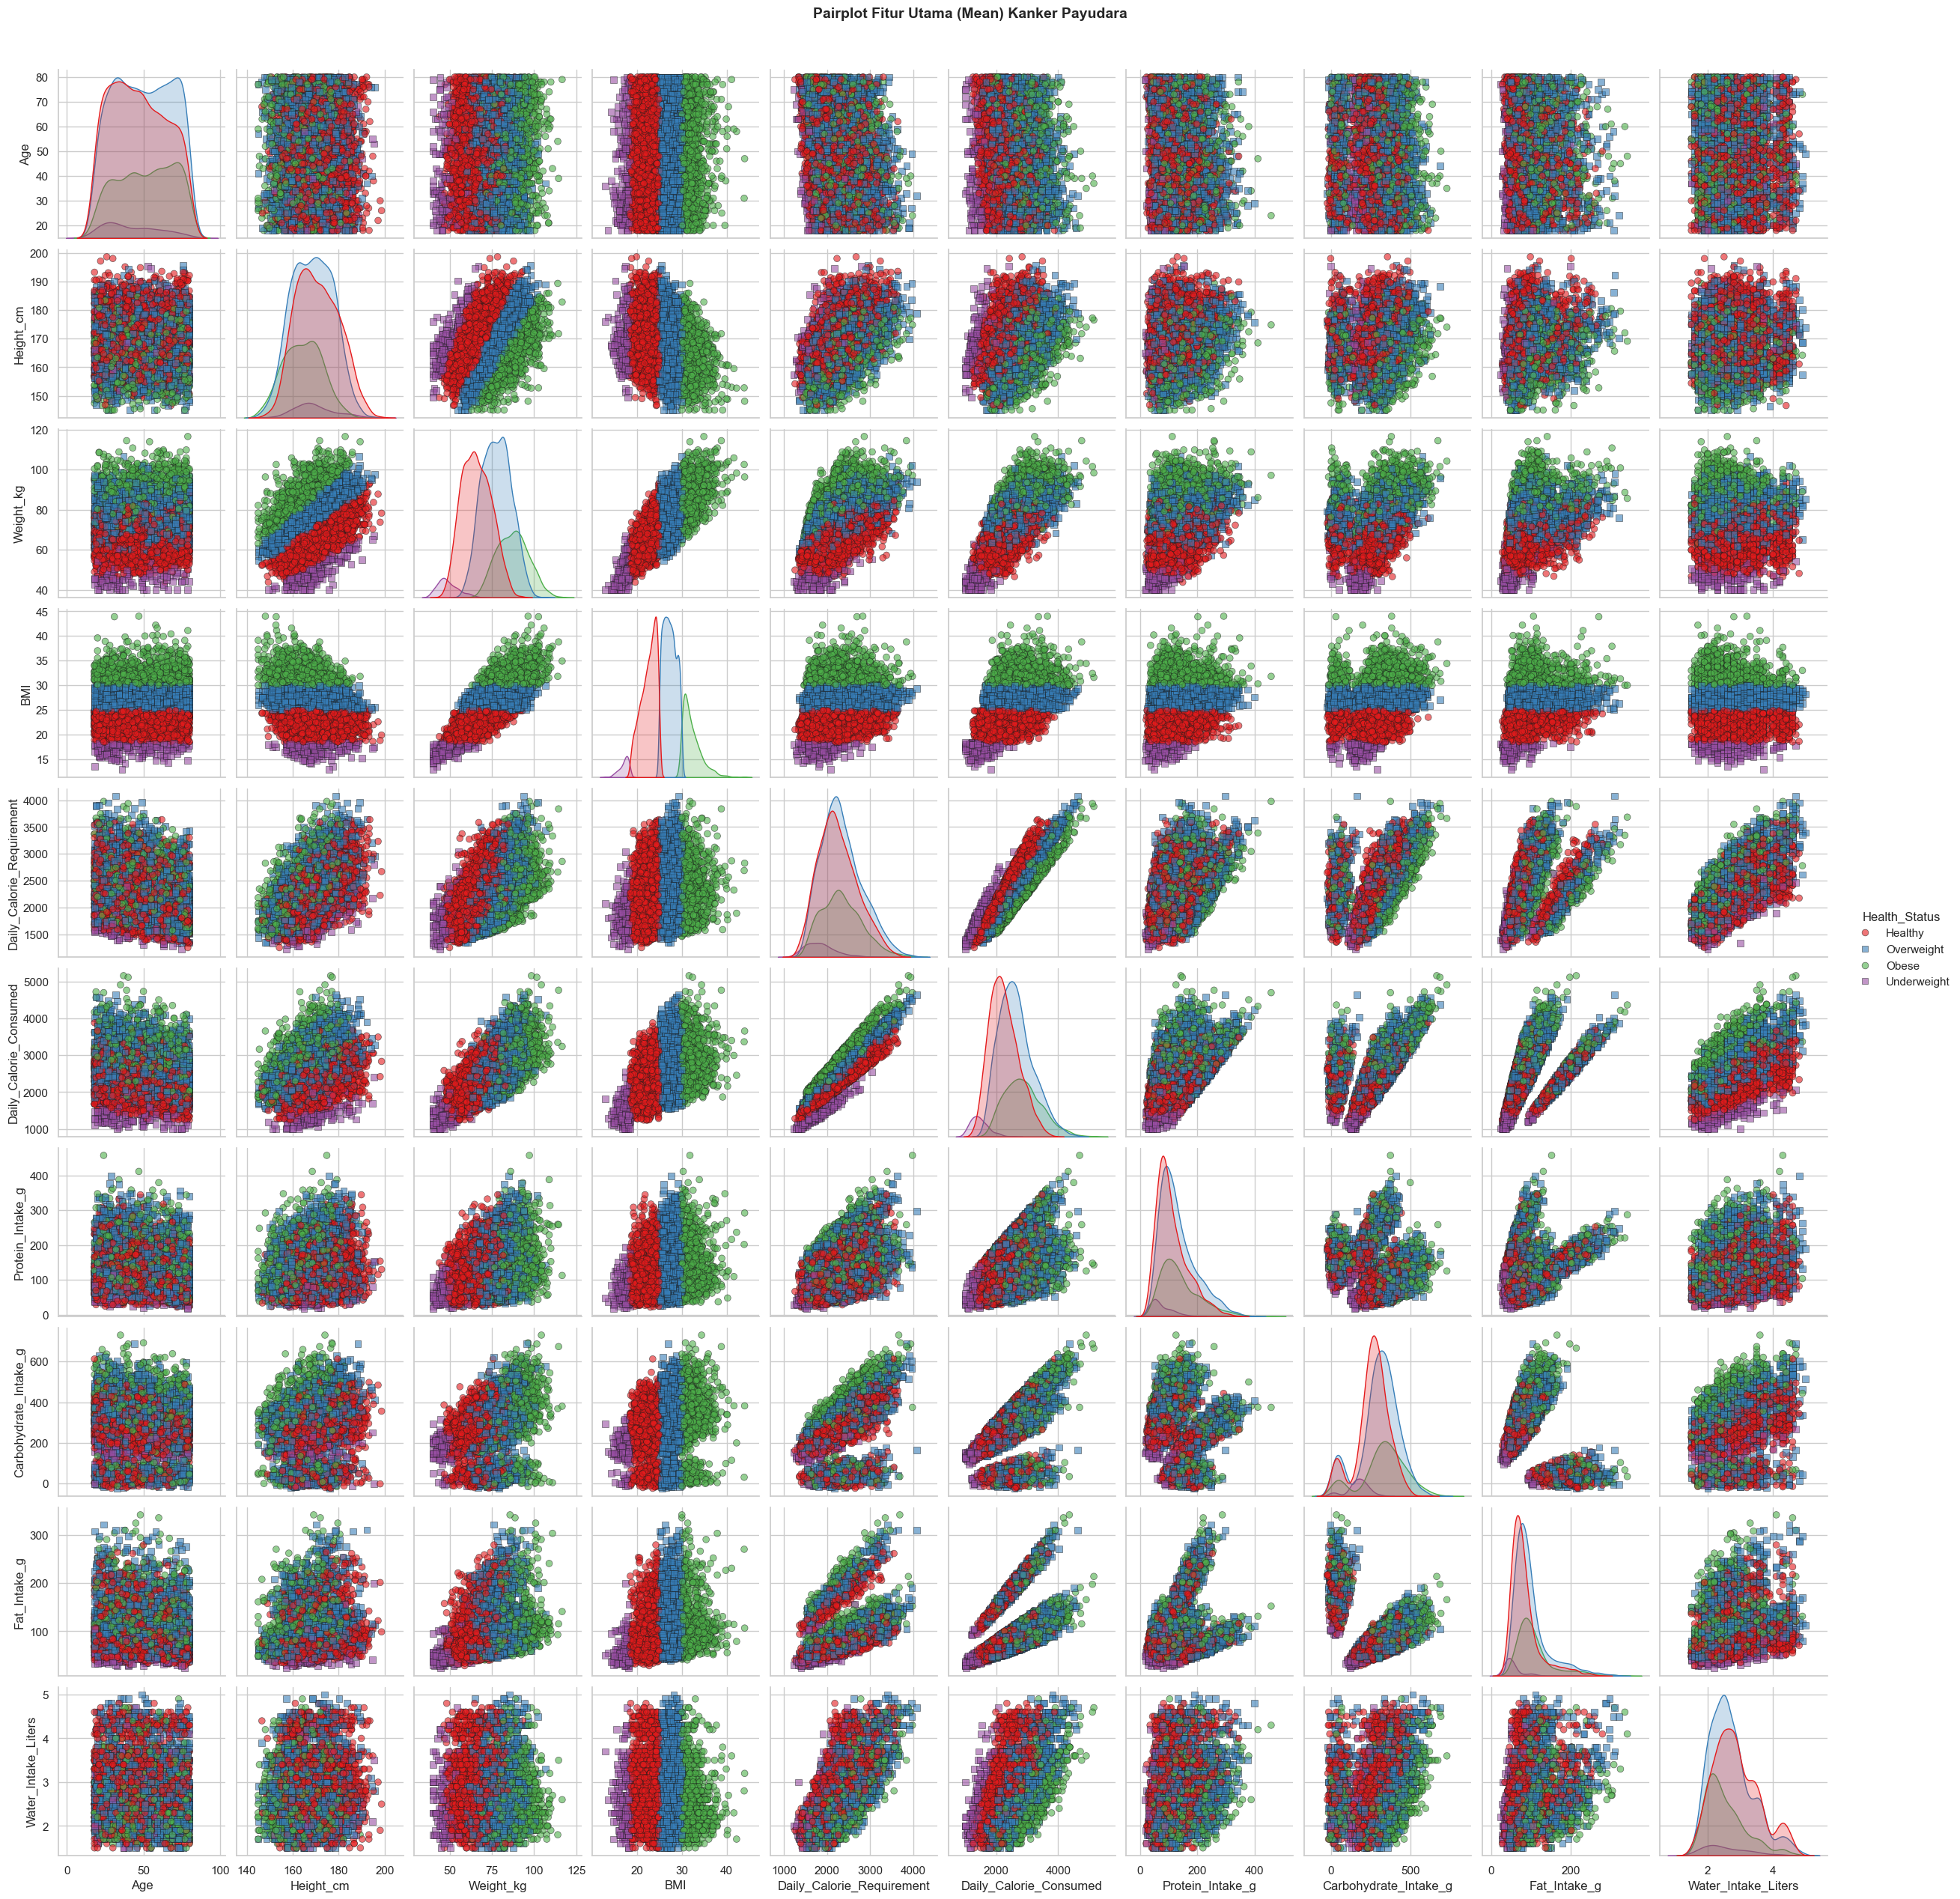

In [6]:
#Type your code here
# 1. Ambil daftar nama kolom yang hanya berisi angka (integer atau float)
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
data = df[numerical_cols + ['Health_Status']]

# 2. Membuat pairplot yang lebih rapih
sns.pairplot(data=data,
             hue='Health_Status',           # Membedakan warna berdasarkan kelas target
             palette='Set1',                # Kombinasi warna yang kontras
             diag_kind='kde',               # Tampilan diagonal berupa kurva distribusi (Density Plot)
             markers=["o", "s"],            # Bentuk titik berbeda ('o' untuk lingkaran, 's' untuk persegi)
             plot_kws={'alpha': 0.6,        # Transparansi titik agar tumpang tindih (overlap) tetap terlihat
                       's': 40,             # Ukuran titik
                       'edgecolor': 'k'})   # Garis tepi hitam pada titik agar lebih tajam

# 3. Menambahkan judul utama (digeser sedikit ke atas menggunakan parameter 'y')
plt.suptitle('Pairplot Fitur Utama (Mean) Kanker Payudara', y=1.02, fontsize=14, fontweight='bold')
plt.show()

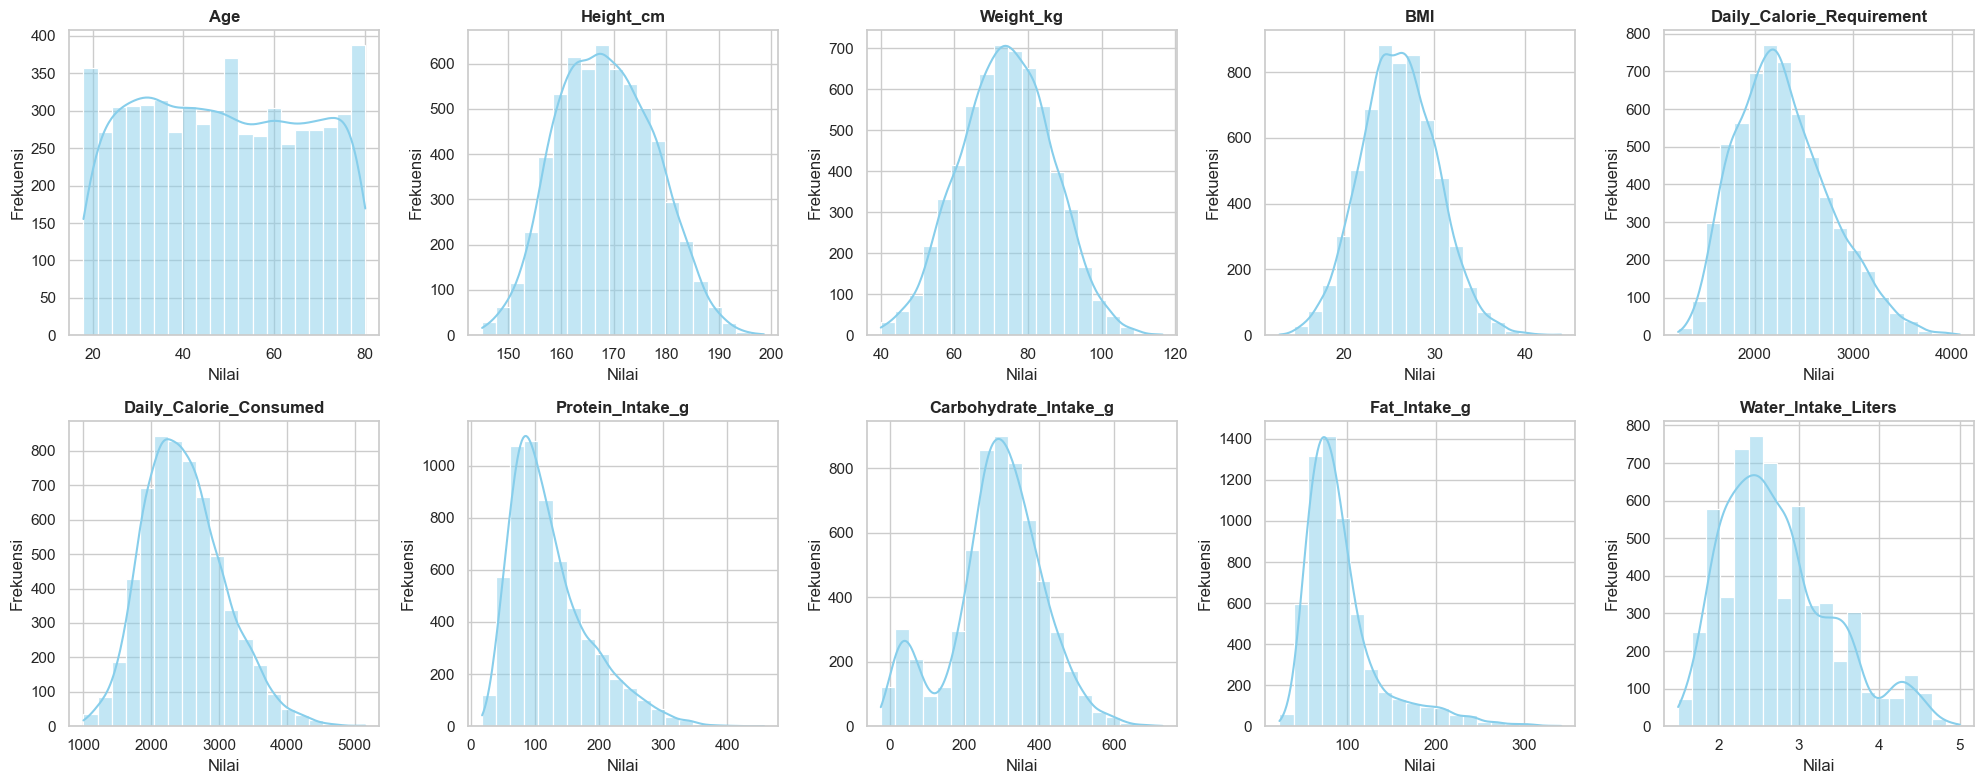

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

# Looping untuk setiap kolom numerik
for i, column in enumerate(numerical_cols):

    # Masukkan data HANYA untuk kolom yang sedang di-looping (df[column])
    sns.histplot(data=df, x=column, bins=20, kde=True, color='skyblue', ax=axes[i])

    # Atur judul dan label
    axes[i].set_title(column, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

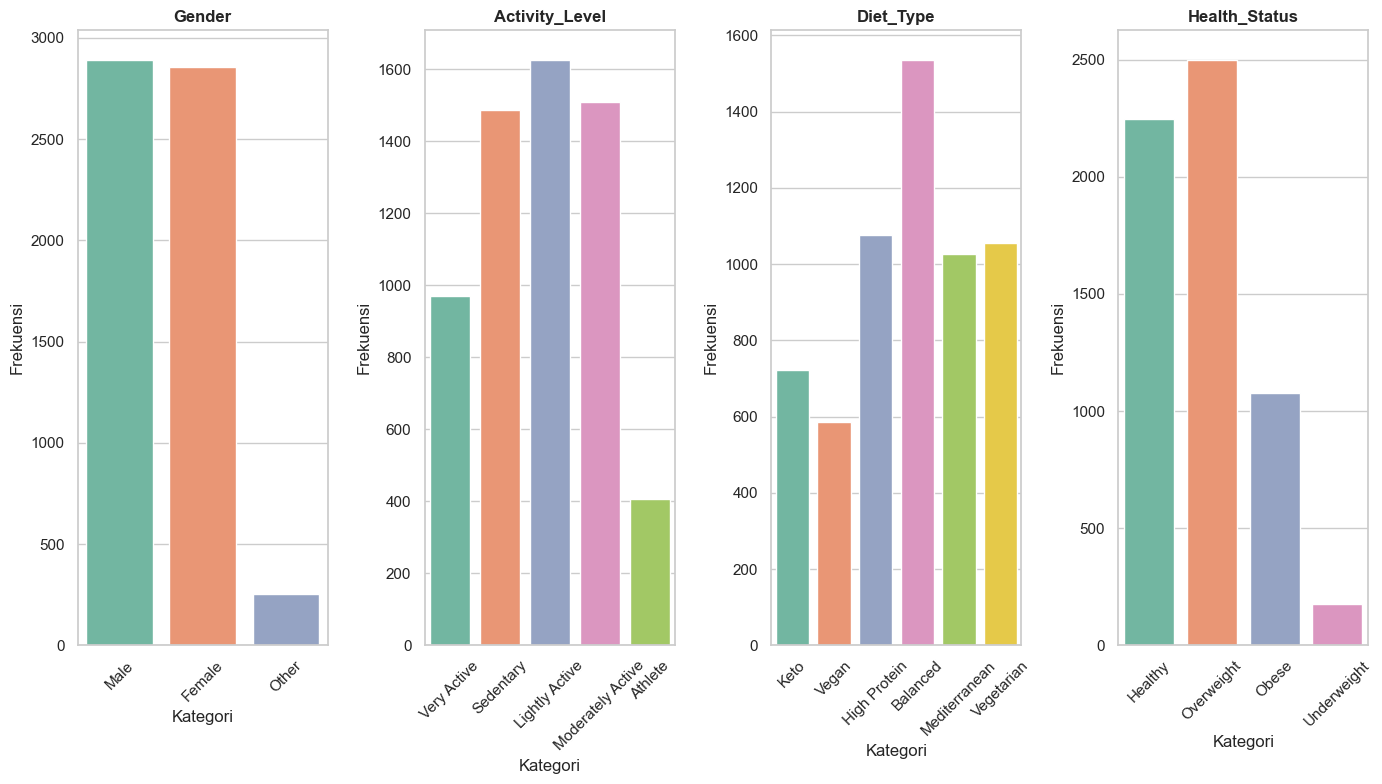

In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns.drop('Person_ID').tolist()

fig, axes = plt.subplots(1, 4, figsize=(14, 8))
axes = axes.flatten()

# 3. Looping untuk setiap kolom kategorikal
for i, column in enumerate(categorical_cols):

    # Gunakan countplot untuk menghitung frekuensi setiap kelas kategori
    sns.countplot(data=df, x=column, palette='Set2', ax=axes[i])

    # Atur judul dan label
    axes[i].set_title(column, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Kategori")
    axes[i].set_ylabel("Frekuensi")
    
    axes[i].tick_params(axis='x', rotation=45)

# 4. Hapus sisa plot/kamar kosong jika jumlah kolom object kurang dari jumlah grid
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

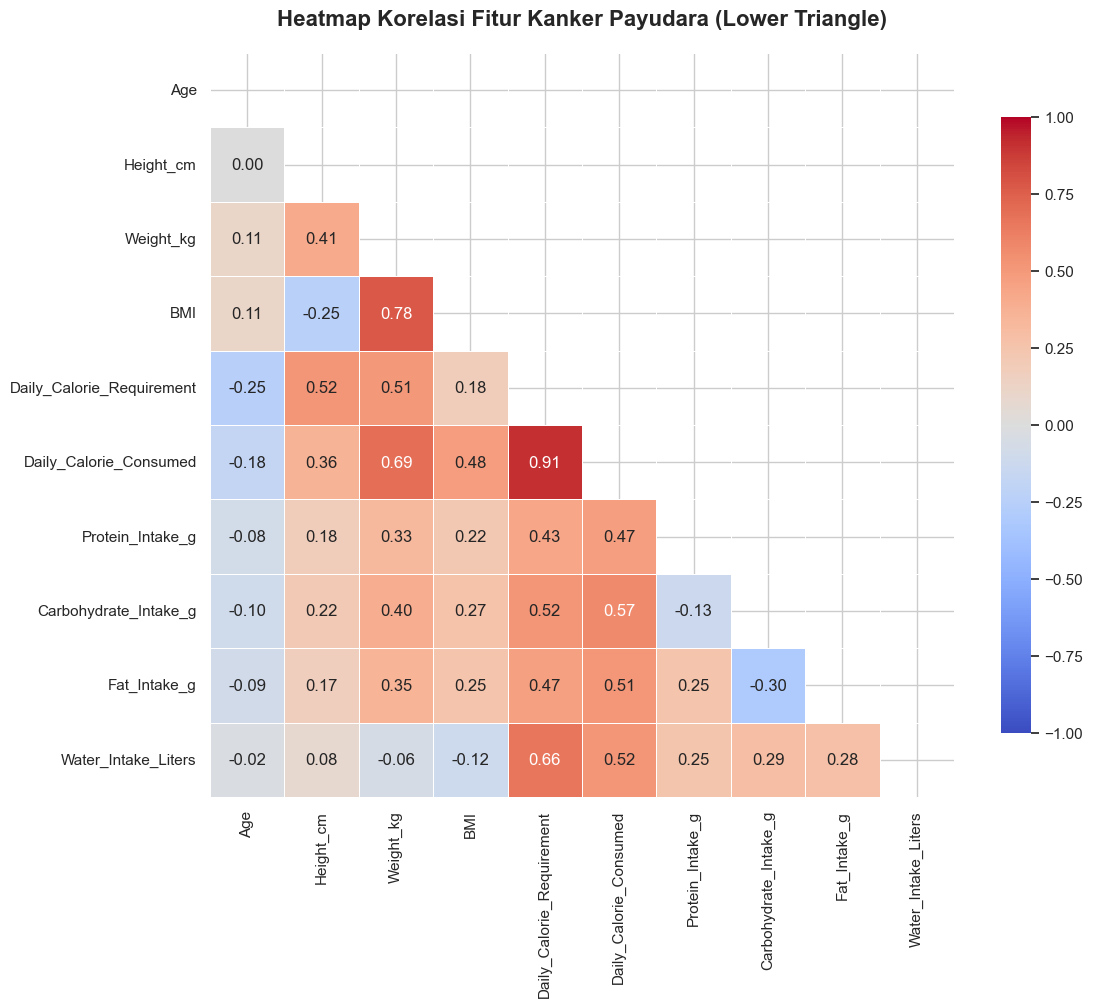

=== Pasangan Fitur dengan Korelasi > 0.6 ===
- Daily_Calorie_Consumed & Daily_Calorie_Requirement = 0.9088
- BMI                    & Weight_kg              = 0.7755
- Daily_Calorie_Consumed & Weight_kg              = 0.6909
- Daily_Calorie_Requirement & Water_Intake_Liters    = 0.6605


In [9]:
# 1. Menghitung matriks korelasi
corr_matrix = df[numerical_cols].corr()

# 2. Membuat mask untuk menyembunyikan segitiga atas
# np.triu akan menghasilkan nilai True pada bagian atas diagonal utama
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Mengatur ukuran kanvas
plt.figure(figsize=(12, 10))

# 4. Membuat Heatmap dengan memasukkan argumen 'mask'
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1, vmax=1,
            linewidths=0.5,
            square=True,
            cbar_kws={"shrink": .8}) # Mengecilkan colorbar agar proporsional dengan bentuk segitiga

# 5. Menambahkan judul
plt.title("Heatmap Korelasi Fitur Kanker Payudara (Lower Triangle)", fontsize=16, fontweight='bold', pad=20)
plt.show()

# Menghitung korelasi, unstack, lalu memfilter yang > 0.7 serta membuang duplikat/self-correlation
corr = df[numerical_cols].corr().unstack()
strong_corr = corr[(corr > 0.6) & (corr.index.get_level_values(0) < corr.index.get_level_values(1))].sort_values(ascending=False)

# Mencetak output
print("=== Pasangan Fitur dengan Korelasi > 0.6 ===")
for (f1, f2), val in strong_corr.items(): print(f"- {f1:<22} & {f2:<22} = {val:.4f}")

- Tingginya korelasi (0.9088) antara asupan dan kebutuhan kalori harian menunjukkan bahwa mayoritas individu memiliki pola makan yang disiplin dan selaras dengan target energi mereka. 
- Sementara itu, korelasi kuat (0.7755) antara BMI dan berat badan adalah hal yang mutlak wajar karena nilai BMI secara matematis memang diturunkan langsung dari angka berat badan. 
- Korelasi moderat lainnya (0.66 - 0.69) sekadar mengonfirmasi pola biologis alami tubuh manusia, di mana tubuh yang lebih berat butuh makan lebih banyak, dan kebutuhan energi yang - tinggi menuntut asupan air yang lebih banyak. 
- Dalam konteks Machine Learning, korelasi antar fitur independen yang melebihi batas 0.6 ini menjadi sinyal peringatan adanya multikolinearitas, sebuah kondisi di mana model klasifikasi bisa kebingungan akibat menerima informasi ganda yang tumpang tindih. Oleh karena itu, sangat disarankan untuk melakukan drop pada kolom Daily_Calorie_Requirement dan Weight_kg sebelum proses pelatihan agar performa model klasifikasi kamu nantinya menjadi jauh lebih efisien, stabil, dan akurat.

# **5. Data Preprocessing**

Pada tahap ini, *data preprocessing* adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model *machine learning*.

Karena kita menggunakan **data tabular terstruktur**, data mentah sering kali mengandung nilai kosong, duplikasi, rentang skala antar fitur yang sangat timpang (misalnya kalori vs liter air), hingga nilai anomali/ekstrem (seperti nilai gizi minus). Jika dibiarkan, hal-hal ini dapat sangat memengaruhi dan mengacaukan kinerja algoritma klasifikasi (seperti *Logistic Regression* atau SVC). Oleh karena itu, proses ini bertujuan untuk membersihkan, menstandarkan, dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang **telah kita lakukan**, yang disesuaikan secara khusus dengan karakteristik dataset kita:

1. **Menghapus Data Kosong (Missing Values):** Memastikan tidak ada sel berlubang (NaN) yang dapat memicu *error* pada algoritma menggunakan `dropna`.
2. **Menghapus Data Duplikat:** Membuang sampel observasi yang identik secara keseluruhan agar model tidak mengalami bias.
3. **Deteksi dan Penanganan Outlier:** Melakukan kombinasi *Drop* untuk data *human error* yang mustahil (nilai minus) dan *Clipping* (menggunakan batas IQR) untuk meratakan nilai gizi ekstrem agar distribusi wajar tetap terjaga tanpa harus membuang sampel observasi.
4. **Standarisasi Fitur:** Menyamakan "bobot" rentang angka di seluruh fitur numerik menggunakan `StandardScaler` agar komputasi model lebih stabil dan seimbang.
5. **Penanganan Fitur Unik & Encoding Data Kategorikal:** Menghapus kolom *noise* (seperti `Person_ID`), lalu mengubah seluruh data teks menjadi angka menggunakan *Ordinal Mapping* untuk data bertingkat (`Activity_Level`, `Health_Status`) dan *One-Hot Encoding* untuk data nominal (`Gender`, `Diet_Type`).

Seluruh tahapan di atas telah dieksekusi secara berurutan agar tidak tumpang tindih, dan hasil akhirnya telah diekspor menjadi format yang 100% siap untuk tahapan *training* model.

In [10]:
# Mengecek jumlah data yang hilang (missing values) dan duplikat
missing_data = df.isnull().sum()
print(f"Jumlah data yang hilang: {missing_data[missing_data > 0]}")

jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah data duplikat: {jumlah_duplikat}")

Jumlah data yang hilang: Series([], dtype: int64)
Jumlah data duplikat: 0


In [11]:
def handle_outliers_iqr(dataframe, column):
    # Hitung Kuartil 1 (25%) dan Kuartil 3 (75%)
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    
    # Hitung Jarak Interkuartil (IQR)
    IQR = Q3 - Q1
    
    # Tentukan batas bawah dan batas atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Lakukan Clipping: Nilai di luar batas akan diubah menjadi nilai batas terdekat
    dataframe[column] = dataframe[column].clip(lower=lower_bound, upper=upper_bound)
    return dataframe

# Buat salinan data agar df asli tetap utuh
df_clean = df.copy()

# Terapkan fungsi outlier ke setiap kolom numerik pada df_clean
df_clean = df[(df['Carbohydrate_Intake_g'] >= 0) & 
              (df['Protein_Intake_g'] >= 0) & 
              (df['Fat_Intake_g'] >= 0)].copy()

for col in numerical_cols:
    df_clean = handle_outliers_iqr(df_clean, col)

# Standardisasi fitur numerik menggunakan StandardScaler
scaler = StandardScaler()

df_scaled = df_clean.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

print(f"Dimensi data scaled + cleaned: {df_scaled.shape[0]} baris x {df_scaled.shape[1]} kolom")
display(df_scaled[numerical_cols].head())

Dimensi data scaled + cleaned: 5946 baris x 15 kolom


,Age,Height_cm,Weight_kg,BMI,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters
0,0.063382,0.852733,0.055441,-0.508339,1.218189,0.230714,1.036069,-2.197396,2.252713,0.846790
1,-1.700264,-0.108538,0.111813,0.193583,-0.818599,-0.748536,-0.547212,0.132034,-1.178818,-1.235145
2,1.055433,-0.731180,1.054036,1.742653,-0.593005,0.087450,1.712670,-0.079076,-0.951686,-0.491597
3,-1.479808,0.077162,-0.580761,-0.677769,0.070885,-0.660892,-0.898295,0.075906,-0.629405,0.251951
4,-1.038897,1.147668,0.095706,-0.629361,-0.302956,-0.928879,-1.522063,-0.043053,-0.475937,-0.789016


In [12]:
# Drop Person_ID
df_scaled = df_scaled.drop(columns=['Person_ID'], errors='ignore')

# mapping target 
target_mapping = {
    'Obese': 0,        # Risiko klinis tertinggi (paling parah)
    'Underweight': 1,  # Risiko kurang gizi / imunitas rendah
    'Overweight': 2,   # Risiko sedang (menuju obesitas)
    'Healthy': 3       # Kondisi ideal (paling sehat)
}

df_scaled['Health_Status'] = df_scaled['Health_Status'].map(target_mapping)

# mapping activity
activity_mapping = {
    'Sedentary': 0,
    'Lightly Active': 1,
    'Moderately Active': 2,
    'Very Active': 3,
    'Athlete': 4
}
df_scaled['Activity_Level'] = df_scaled['Activity_Level'].map(activity_mapping)

# One-Hot Encoding untuk kolom Gender dan Diet_Type
df_final = pd.get_dummies(df_scaled, columns=['Gender', 'Diet_Type'], drop_first=True)

bool_cols = df_final.select_dtypes(include=['bool']).columns
df_final[bool_cols] = df_final[bool_cols].astype(int)

print(f"Dimensi data final: {df_final.shape[0]} baris x {df_final.shape[1]} kolom")
display(df_final.head())

Dimensi data final: 5946 baris x 19 kolom


,Age,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Health_Status,Gender_Male,Gender_Other,Diet_Type_High Protein,Diet_Type_Keto,Diet_Type_Mediterranean,Diet_Type_Vegan,Diet_Type_Vegetarian
0,0.063382,0.852733,0.055441,-0.508339,3,1.218189,0.230714,1.036069,-2.197396,2.252713,0.846790,3,1,0,0,1,0,0,0
1,-1.700264,-0.108538,0.111813,0.193583,0,-0.818599,-0.748536,-0.547212,0.132034,-1.178818,-1.235145,2,0,0,0,0,0,1,0
2,1.055433,-0.731180,1.054036,1.742653,1,-0.593005,0.087450,1.712670,-0.079076,-0.951686,-0.491597,0,0,0,1,0,0,0,0
3,-1.479808,0.077162,-0.580761,-0.677769,2,0.070885,-0.660892,-0.898295,0.075906,-0.629405,0.251951,3,0,0,0,0,0,0,0
4,-1.038897,1.147668,0.095706,-0.629361,0,-0.302956,-0.928879,-1.522063,-0.043053,-0.475937,-0.789016,3,1,0,0,0,0,0,0


In [13]:
# Mengekspor dataframe hasil akhir ke dalam file CSV
df_final.to_csv('healthy_diet_calorie_intake_preprocessing.csv', index=False)

print("Data berhasil diekspor menjadi 'healthy_diet_calorie_intake_preprocessing.csv'!")

Data berhasil diekspor menjadi 'healthy_diet_calorie_intake_preprocessing.csv'!
